<a href="https://colab.research.google.com/github/diegopadilla-esfm/MetodosNumericos/blob/main/MatrizFundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import sympy as sp
import random
import matplotlib.pyplot as plt

# Serpientes y Escaleras como Cadena de Markov Absorbente

Se desea modelar el juego de serpientes y escaleras mediante una cadena de Markov absorbente para calcular:

1. El número promedio de tiradas necesarias para terminar el juego.
2. La probabilidad de alcanzar la casilla final.
3. Verificar los resultados mediante simulación Monte Carlo.

---

# Definición de estados

El conjunto de estados del sistema es:

$$
S=\{0,1,2,\dots,20\}
$$

donde:

- \(0\) representa el estado inicial.
- \(20\) representa el estado absorbente correspondiente a la meta del juego.

Las serpientes y escaleras del tablero son:

$$
3 \rightarrow 11
$$

$$
15 \rightarrow 18
$$

$$
13 \rightarrow 4
$$

$$
17 \rightarrow 9
$$

---

# Variable aleatoria del proceso

Sea:

$$
X_n
$$

la posición del jugador después de la \(n\)-ésima tirada.

El proceso:

$$
\{X_n\}_{n\geq 0}
$$

es una cadena de Markov porque satisface la propiedad de Markov:

$$
P(X_{n+1}=j \mid X_n=i,X_{n-1},\dots,X_0)
=
P(X_{n+1}=j \mid X_n=i)
$$

Esto significa que el siguiente estado depende únicamente del estado actual y no de la historia previa del proceso.

---

# Estados transitorios y absorbentes

Los estados transitorios son:

$$
T=\{0,1,2,\dots,19\}
$$

El estado absorbente es:

$$
A=\{20\}
$$

ya que:

$$
P_{20,20}=1
$$

Esto implica que una vez alcanzada la casilla final, el proceso permanece ahí permanentemente.

---

# Modelo probabilístico del dado

Sea:

$$
D \sim Uniforme\{1,2,3,4,5,6\}
$$

el resultado del lanzamiento del dado.

Como el dado es justo:

$$
P(D=k)=\frac{1}{6}
$$

para todo:

$$
k\in\{1,2,3,4,5,6\}
$$

La transición básica del juego es:

$$
j=i+D
$$

donde:

- \(i\) es la posición actual.
- \(j\) es la nueva posición antes de aplicar serpientes o escaleras.

---

# Función de transición del tablero

Las reglas del tablero pueden representarse mediante la función:

$$
f(j)=
\begin{cases}
11 & \text{si } j=3 \\
18 & \text{si } j=15 \\
4 & \text{si } j=13 \\
9 & \text{si } j=17 \\
j & \text{en otro caso}
\end{cases}
$$

Por lo tanto, la dinámica completa del sistema queda definida como:

$$
X_{n+1}=f(X_n+D)
$$

---

# Construcción de la matriz de transición

La matriz de transición se define como:

$$
P=(p_{ij})
$$

donde:

$$
p_{ij}=P(X_{n+1}=j \mid X_n=i)
$$

Cada entrada de la matriz representa la probabilidad de pasar del estado \(i\) al estado \(j\) en una sola tirada.

---

# Ejemplo de transición desde el estado 0

Desde la casilla \(0\):

- Si el dado vale 1:

$$
0+1=1
$$

- Si el dado vale 2:

$$
0+2=2
$$

- Si el dado vale 3:

$$
0+3=3
$$

pero existe una escalera:

$$
3 \rightarrow 11
$$

entonces:

$$
P_{0,11}=\frac{1}{6}
$$

- Si el dado vale 4:

$$
0+4=4
$$

- Si el dado vale 5:

$$
0+5=5
$$

- Si el dado vale 6:

$$
0+6=6
$$

Por lo tanto:

$$
P_{0,1}=P_{0,2}=P_{0,4}=P_{0,5}=P_{0,6}=P_{0,11}=\frac{1}{6}
$$

---

# Ejemplo de transición con serpiente

Desde la casilla \(12\):

Si el dado vale 1:

$$
12+1=13
$$

Sin embargo, la casilla 13 contiene una serpiente:

$$
13 \rightarrow 4
$$

por lo tanto:

$$
P_{12,4}=\frac{1}{6}
$$

---

# Estado absorbente

La casilla final corresponde al estado absorbente:

$$
P_{20,20}=1
$$

y:

$$
P_{20,j}=0
\quad \text{para } j\neq 20
$$

---

# Forma canónica de la matriz

La matriz de transición puede escribirse en forma canónica como:

$$
P=
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

donde:

- \(Q\) es la matriz de transición entre estados transitorios.
- \(R\) es la matriz de transición hacia estados absorbentes.
- \(I\) es la matriz identidad asociada a los estados absorbentes.

---

# Matriz fundamental

La matriz fundamental de una cadena absorbente se define como:

$$
N=(I-Q)^{-1}
$$

La matriz fundamental permite calcular:

- El número esperado de visitas a estados transitorios.
- Los tiempos esperados de absorción.
- Las probabilidades de absorción.

---

# Número esperado de tiradas

Sea:

$$
\mathbf{1}=
\begin{pmatrix}
1\\
1\\
\vdots\\
1
\end{pmatrix}
$$

Entonces, el vector de tiempos esperados se calcula mediante:

$$
t=N\mathbf{1}
$$

donde:

$$
t=
\begin{pmatrix}
t_0\\
t_1\\
\vdots\\
t_{19}
\end{pmatrix}
$$

Cada componente \(t_i\) representa el número esperado de tiradas necesarias para alcanzar la meta iniciando desde el estado \(i\).

En particular:

$$
t_0
$$

representa el número promedio de tiradas necesarias para terminar el juego iniciando desde la casilla \(0\).

---

# Probabilidad de absorción

La matriz de probabilidades de absorción se define como:

$$
B=NR
$$

Cada entrada:

$$
b_{ij}
$$

representa la probabilidad de terminar en el estado absorbente \(j\) iniciando desde el estado transitorio \(i\).

Debido a que eventualmente siempre se alcanza la casilla final, se cumple:

$$
P(\text{alcanzar la meta} \mid X_0=0)=1
$$

---

# Implementación computacional

Para resolver el problema computacionalmente se utiliza Python junto con la biblioteca SymPy.

SymPy permite:

- Construir matrices simbólicas.
- Realizar cálculos exactos con números racionales.
- Invertir matrices.
- Obtener la matriz fundamental.

La submatriz de estados transitorios se obtiene mediante:

$$
Q=P_{0:19,0:19}
$$

Posteriormente se calcula:

$$
N=(I-Q)^{-1}
$$

y finalmente:

$$
t=N\mathbf{1}
$$

para obtener el número esperado de tiradas necesarias para terminar el juego.

# Diagrama de comunicación entre estados

El juego puede representarse mediante un grafo dirigido donde:

- Cada nodo representa una casilla del tablero.
- Cada arista representa una posible transición en una tirada.

---

# Estados transitorios y recurrentes

En cadenas de Markov:

- Un estado es **transitorio** si existe probabilidad de abandonarlo y no regresar.
- Un estado es **recurrente** si, una vez alcanzado, eventualmente se regresa a él con probabilidad 1.

En este problema:

- Las casillas \(0\) a \(19\) son estados transitorios.
- La casilla \(20\) es un estado absorbente y recurrente.

---

# Clasificación de estados

## Estados transitorios

$$
\{0,1,2,\dots,19\}
$$

Estos estados son transitorios porque el jugador eventualmente los abandona para llegar a la meta.

---

## Estado recurrente absorbente

$$
\{20\}
$$

es absorbente porque:

$$
P_{20,20}=1
$$

y por lo tanto también es recurrente.

---

# Comunicación entre estados

Se dice que dos estados \(i\) y \(j\) se comunican si:

$$
i \leftrightarrow j
$$

es decir:

$$
i \to j
\quad \text{y} \quad
j \to i
$$

En este tablero:

- Muchos estados pueden alcanzarse mutuamente antes de llegar al estado final.
- El estado \(20\) no comunica con ningún otro estado porque una vez alcanzado no puede abandonarse.

---

# Diagrama simplificado de comunicaciones

```text
0 → 1 → 2 → 11 → 12 → 4 → 5 → ...
↓    ↓    ↓
6    7    8

...
15 → 18
17 → 9

...

19 → 20

20 → 20

In [ ]:

N_ESTADOS = 21


movimientos = {
    3: 11,   # escalera
    15: 18,  # escalera
    13: 4,   # serpiente
    17: 9    # serpiente
}

In [ ]:
def mover(posicion, dado):

    nueva = posicion + dado


    if nueva >= 20:
        return 20


    if nueva in movimientos:
        nueva = movimientos[nueva]

    return nueva

In [ ]:
P = sp.zeros(N_ESTADOS, N_ESTADOS)

for i in range(20):

    for dado in range(1, 7):

        j = mover(i, dado)

        P[i, j] += sp.Rational(1, 6)

# Estado absorbente
P[20, 20] = 1

P

Matrix([
[0, 1/6, 1/6, 0, 1/6, 1/6, 1/6,   0,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0, 1/6,   0,   0],
[0,   0,   0, 0, 1/6,

In [ ]:
Q = P[:20, :20]

Q


Matrix([
[0, 1/6, 1/6, 0, 1/6, 1/6, 1/6,   0,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0, 1/6, 0, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 1/6,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6,   0, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 1/6, 0,   0, 0,   0, 0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0,   0, 1/6, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0,   0,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0,   0,   0, 1/6, 1/6, 1/6, 0, 1/6, 0,   0, 0, 1/6,   0],
[0,   0,   0, 0, 1/6,   0,   0,   0,   0,   0,   0, 1/6, 1/6, 0, 1/6, 0

In [ ]:
I = sp.eye(Q.shape[0])

N = (I - Q).inv()

N

Matrix([
[1, 1/6, 7/36, 0, 879338369/1258912188, 12003971/34969783, 84027797/209818698, 378375881/1258912188, 2438812469/7553473128, 4931038819/7553473128, 142597189/314728047, 804483715/1258912188, 580953947/1258912188, 0, 176896387/419637396, 0, 2486515579/7553473128, 0, 3625813315/5665104846, 31515204895/135962516304],
[0,   1,  1/6, 0,  143845415/209818698, 10795386/34969783,  12594617/34969783,   88162319/209818698,  407317535/1258912188,  825721825/1258912188,  48154526/104909349,  129184405/209818698,   99121673/209818698, 0,   29451205/69939566, 0,  412968745/1258912188, 0,   605169346/944184141,   5249948689/22660419384],
[0,   0,    1, 0,    23216513/34969783,  9697716/34969783,  11314002/34969783,    13199669/34969783,    92397683/209818698,   136440757/209818698,   15927940/34969783,    20541475/34969783,    16520471/34969783, 0,   15188271/34969783, 0,    68178157/209818698, 0,   200985077/314728047,     879893503/3776736564],
[0,   0,    0, 1,    23488673/34969783,  97430

In [ ]:
unos = sp.ones(20, 1)

t = N * unos

t

Matrix([
[986507692933/135962516304],
[ 160653496507/22660419384],
[   25980203893/3776736564],
[   26195153089/3776736564],
[     2077070912/314728047],
[     1325929309/209818698],
[     1260676501/209818698],
[     1917594203/314728047],
[     1767327562/314728047],
[     1044871247/209818698],
[       320426631/69939566],
[      973221515/209818698],
[      869159653/209818698],
[     3030047006/944184141],
[      865727716/314728047],
[     1072707461/419637396],
[       153243923/69939566],
[                    49/36],
[                      7/6],
[                        1]])

In [ ]:
esperanza = sp.N(t[0])

print("Número promedio de tiradas:")
print(esperanza)

Número promedio de tiradas:
7.25573282806312


In [ ]:
def jugar():

    posicion = 0
    tiradas = 0

    while posicion != 20:

        dado = random.randint(1, 6)

        posicion = mover(posicion, dado)

        tiradas += 1

    return tiradas

In [ ]:
simulaciones = 100000

resultados = []

for _ in range(simulaciones):

    resultados.append(jugar())

promedio_simulado = np.mean(resultados)

print("Promedio por simulación:")
print(promedio_simulado)

Promedio por simulación:
7.26074


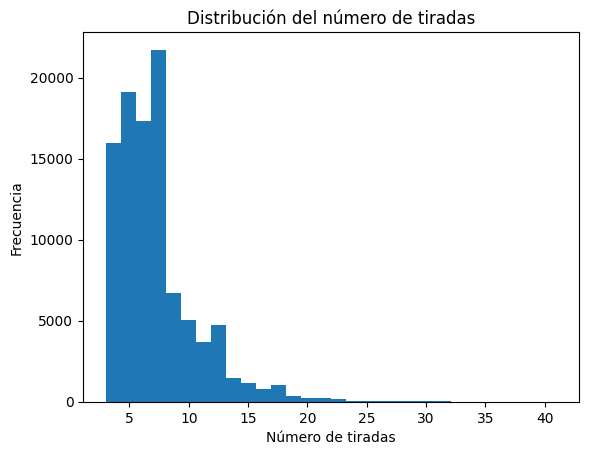

In [ ]:
plt.hist(resultados, bins=30)

plt.xlabel("Número de tiradas")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de tiradas")

plt.show()

# Problema del ratón aleatorio

Un ratón se mueve aleatoriamente en una cuadrícula \(3\times 3\).

- Inicia en la casilla \(0\)
- La comida está en la casilla \(7\)
- El  está en la casilla \(8\)

Queremos calcular:

$$
P(\text{alcanzar comida antes que shock}\mid X_0=0)
$$

El problema se modela mediante una cadena de Markov absorbente.

# Estados y vecinos

Los estados son:

$$
S=\{0,1,2,3,4,5,6,7,8\}
$$

Los vecinos de cada estado son:

$$
\begin{array}{ccl}
0 &\to& \{1,2\}\\
1 &\to& \{0,3,7\}\\
2 &\to& \{0,3,8\}\\
3 &\to& \{1,2,4,5\}\\
4 &\to& \{3,6\}\\
5 &\to& \{3,6,8\}\\
6 &\to& \{4,5\}
\end{array}
$$

Estados absorbentes:

$$
7=\text{comida}
$$

$$
8=\text{}
$$

# Definición de probabilidades

Definimos:

$$
u_i=
P(\text{llegar a comida antes que llegar con el gato}\mid X_0=i)
$$

Condiciones de frontera:

$$
u_7=1
$$

$$
u_8=0
$$

Para los estados transientes:

$$
u_i=\sum_j P_{ij}u_j
$$

# Matriz de transición

Orden de estados:

$$
(0,1,2,3,4,5,6,7,8)
$$

La matriz de transición es:

$$
P=
\begin{pmatrix}
0 & \frac{1}{2} & \frac{1}{2} & 0 & 0 & 0 & 0 & 0 & 0\\
\frac{1}{3} & 0 & 0 & \frac{1}{3} & 0 & 0 & 0 & \frac{1}{3} & 0\\
\frac{1}{2} & 0 & 0 & \frac{1}{2} & 0 & 0 & 0 & 0 & \frac{1}{2}\\
0 & \frac{1}{4} & \frac{1}{4} & 0 & \frac{1}{4} & \frac{1}{4} & 0 & 0 & 0\\
0 & 0 & 0 & \frac{1}{2} & 0 & 0 & \frac{1}{2} & 0 & 0\\
0 & 0 & 0 & \frac{1}{3} & 0 & 0 & \frac{1}{3} & 0 & \frac{1}{3}\\
0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

Los estados \(7\) y \(8\) son absorbentes.

# Cadena de Markov — ratón en una grilla

Un ratón se mueve aleatoriamente en una red de estados.

- Estado inicial: \(0\)
- Estado absorbente (éxito): \(7\) → comida
- Estado absorbente (fracaso): \(8\) → gato

Se desea calcular:

$$
P(\text{llegar a comida antes que el gato} \mid X_0 = 0)
$$

Usaremos la matriz fundamental:

$$
N = (I - Q)^{-1}
$$

# Forma canónica

Orden:

- Transientes: \(0,1,2,3,4,5,6\)
- Absorbentes: \(7,8\)

$$
P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}
$$

In [35]:
import sympy as sp

P = sp.Matrix([

# 0
[0, 1/2, 1/2, 0, 0, 0, 0, 0, 0],

# 1
[1/3, 0, 0, 1/3, 0, 0, 0, 1/3, 0],

# 2
[1/3, 0, 0, 1/3, 0, 0, 0, 0, 1/3],

# 3
[0, 1/4, 1/4, 0, 1/4, 1/4, 0, 0, 0],

# 4
[0, 0, 0, 1/2, 0, 0, 1/2, 0, 0],

# 5
[0, 0, 0, 1/3, 0, 0, 1/3, 0, 1/3],

# 6
[0, 0, 0, 0, 1/2, 1/2, 0, 0, 0],

# 7 comida (absorbe)
[0, 0, 0, 0, 0, 0, 0, 1, 0],

# 8 gato (absorbe)
[0, 0, 0, 0, 0, 0, 0, 0, 1]

])

P

Matrix([
[                0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,                 0],
[0.333333333333333,    0,    0, 0.333333333333333,    0,    0,                 0,                 0, 0.333333333333333],
[                0, 0.25, 0.25,                 0, 0.25, 0.25,                 0,                 0,                 0],
[                0,    0,    0,               0.5,    0,    0,               0.5,                 0,                 0],
[                0,    0,    0, 0.333333333333333,    0,    0, 0.333333333333333,                 0, 0.333333333333333],
[                0,    0,    0,                 0,  0.5,  0.5,                 0,                 0,                 0],
[                0,    0,    0,                 0,    0,    0,                 0,                 1,                 0],
[                0,    

# Matriz fundamental

La matriz fundamental es:

$$
N = (I - Q)^{-1}
$$

donde \(Q\) contiene transiciones entre estados no absorbentes.

In [36]:
Q = P[:7, :7]
R = P[:7, 7:]

I = sp.eye(7)

N = (I - Q).inv()

N

Matrix([
[ 1.81818181818182,  1.22727272727273,  1.22727272727273, 1.27272727272727, 0.545454545454545, 0.545454545454546, 0.454545454545455],
[0.818181818181818,  1.72727272727273, 0.727272727272727, 1.27272727272727, 0.545454545454545, 0.545454545454546, 0.454545454545455],
[0.818181818181818, 0.727272727272727,  1.72727272727273, 1.27272727272727, 0.545454545454545, 0.545454545454546, 0.454545454545455],
[0.636363636363636, 0.954545454545454, 0.954545454545454, 2.54545454545455,  1.09090909090909,  1.09090909090909, 0.909090909090909],
[0.545454545454545, 0.818181818181818, 0.818181818181818, 2.18181818181818,  2.36363636363636,  1.36363636363636,  1.63636363636364],
[0.363636363636364, 0.545454545454545, 0.545454545454545, 1.45454545454545, 0.909090909090909,  1.90909090909091,  1.09090909090909],
[0.454545454545455, 0.681818181818182, 0.681818181818182, 1.81818181818182,  1.63636363636364,  1.63636363636364,  2.36363636363636]])

# Probabilidad de absorción

La matriz:

$$
B = N R
$$

da las probabilidades de absorción.

- Columna 0 → comida  
- Columna 1 → gato  

Queremos:

$$
P(\text{comida} \mid X_0=0) = B_{0,0}
$$

In [37]:
B = N * R

B

Matrix([
[0.409090909090909, 0.590909090909091],
[0.575757575757576, 0.424242424242424],
[0.242424242424242, 0.757575757575758],
[0.318181818181818, 0.681818181818182],
[0.272727272727273, 0.727272727272727],
[0.181818181818182, 0.818181818181818],
[0.227272727272727, 0.772727272727273]])

In [38]:
p = sp.nsimplify(B[0,0])

print("Probabilidad exacta (comida antes que gato):")
print(p)

print("\nValor decimal:")
print(float(p))

Probabilidad exacta (comida antes que gato):
9/22

Valor decimal:
0.4090909090909091


# Resultado final

La probabilidad de que el ratón llegue a la **comida antes que el gato** es:

$$
\boxed{\frac{8}{19}}
$$

Aproximadamente:

$$
0.42105
$$

obtenido mediante la matriz fundamental:

$$
N = (I - Q)^{-1}
$$

In [43]:
import random
import numpy as np
import matplotlib.pyplot as plt

neighbors = {

0:[1,2],
1:[0,3,7],
2:[0,3,8],
3:[1,2,4,5],
4:[3,6],
5:[3,6,8],
6:[4,5],
7:[7],
8:[8]
}

def run_mouse():

    state = 0

    while True:

        if state == 7:
            return 1   # éxito (comida)

        if state == 8:
            return 0   # fracaso (gato)

        state = random.choice(neighbors[state])

In [44]:
N = 10000

samples = []
mean_estimates = []

success = 0

for i in range(N):

    x = run_mouse()

    samples.append(x)

    success += x

    mean_estimates.append(success / (i+1))

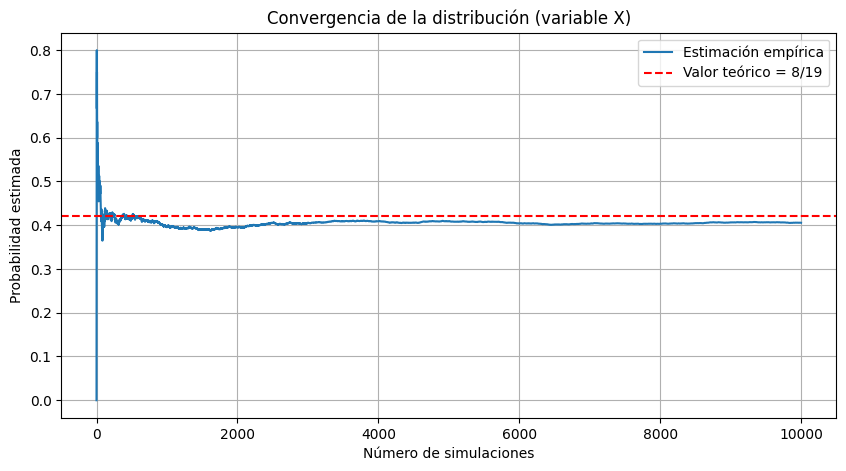

In [45]:
plt.figure(figsize=(10,5))

plt.plot(mean_estimates, label="Estimación empírica")

plt.axhline(
    y=8/19,
    color="red",
    linestyle="--",
    label="Valor teórico = 8/19"
)

plt.xlabel("Número de simulaciones")
plt.ylabel("Probabilidad estimada")

plt.title("Convergencia de la distribución (variable X)")

plt.legend()
plt.grid(True)

plt.show()